C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from curr

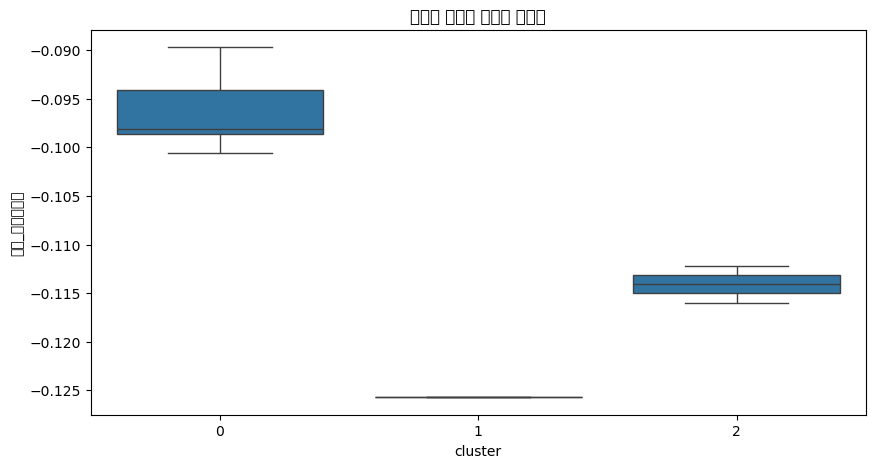

           지역  평균_소비변화율    scaled  cluster
0   인천광역시 강화군 -0.100572  0.203211        0
1   인천광역시 계양구 -0.098283  0.414508        0
3    인천광역시 동구 -0.095308  0.689123        0
4  인천광역시 미추홀구 -0.089701  1.206732        0
5   인천광역시 부평구 -0.098066  0.434527        0
6    인천광역시 서구 -0.099038  0.344821        0
8   인천광역시 옹진군 -0.092910  0.910455        0
7   인천광역시 연수구 -0.125703 -2.116758        1
2   인천광역시 남동구 -0.112175 -0.867954        2
9    인천광역시 중구 -0.115974 -1.218664        2


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로딩
df = pd.read_csv("C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv", encoding='utf-8')

# 날짜 변환
df['일자'] = pd.to_datetime(df['일자'])

# 필요한 컬럼만 추출
df = df[['일자', '지역', '전체금액', '캐시백_상향', '캐시백_하향', '캐시백_변동_소비변화율']]

# 캐시백 이벤트가 있는 경우만 필터링 (상향 or 하향)
df_event = df[(df['캐시백_상향'] == 1) | (df['캐시백_하향'] == 1)].copy()

# 지역별 캐시백 변화 시 소비금액 변화율 평균 구하기
region_sensitivity = df_event.groupby('지역')['캐시백_변동_소비변화율'].mean().reset_index()
region_sensitivity.columns = ['지역', '평균_소비변화율']

# 표준화
scaler = StandardScaler()
region_sensitivity['scaled'] = scaler.fit_transform(region_sensitivity[['평균_소비변화율']])

# 군집화 (예: 3개 군집)
kmeans = KMeans(n_clusters=3, random_state=42)
region_sensitivity['cluster'] = kmeans.fit_predict(region_sensitivity[['scaled']])

# 결과 시각화
plt.figure(figsize=(10, 5))
sns.boxplot(data=region_sensitivity, x='cluster', y='평균_소비변화율')
plt.title('지역별 캐시백 민감도 군집화')
plt.show()

# 결과 확인
print(region_sensitivity.sort_values('cluster'))


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from curr

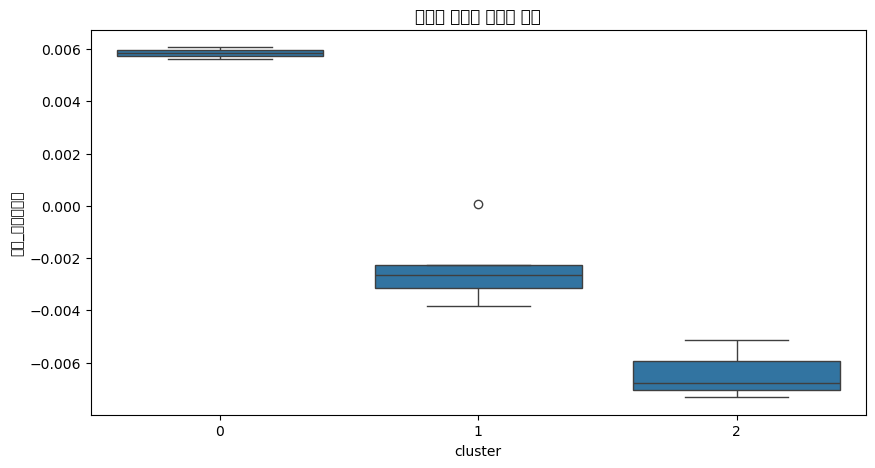

           지역  평균_소비변화율    scaled  cluster
0   인천광역시 강화군  0.006073  1.820910        0
8   인천광역시 옹진군  0.005612  1.715919        0
2   인천광역시 남동구 -0.003131 -0.272473        1
3    인천광역시 동구  0.000072  0.456044        1
4  인천광역시 미추홀구 -0.002644 -0.161728        1
6    인천광역시 서구 -0.003829 -0.431093        1
7   인천광역시 연수구 -0.002265 -0.075495        1
1   인천광역시 계양구 -0.007324 -1.226112        2
5   인천광역시 부평구 -0.005128 -0.726495        2
9    인천광역시 중구 -0.006768 -1.099477        2


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv", encoding='utf-8')
df['일자'] = pd.to_datetime(df['일자'])

# 이벤트 발생 여부 컬럼 생성
df['캐시백_변동'] = df[['캐시백_상향', '캐시백_하향']].sum(axis=1)
df = df.sort_values(['지역', '일자'])

# 지역별 이벤트 발생 일자 기준으로 소비 변화율 계산
results = []

for region in df['지역'].unique():
    region_df = df[df['지역'] == region].reset_index(drop=True)
    for i, row in region_df.iterrows():
        if row['캐시백_변동'] == 1:
            idx = i
            # 이전 7일 / 이후 7일 평균 소비금액
            before = region_df.loc[max(0, idx-7):idx-1, '전체금액'].mean()
            after = region_df.loc[idx+1:idx+7, '전체금액'].mean()

            # NaN 방지
            if pd.notnull(before) and pd.notnull(after) and before > 0:
                rate = (after - before) / before
                results.append({'지역': region, '소비변화율': rate})

# 결과 데이터프레임
response_df = pd.DataFrame(results)

# 지역별 평균 소비 변화율
region_response = response_df.groupby('지역')['소비변화율'].mean().reset_index()
region_response.columns = ['지역', '평균_소비변화율']

# 표준화
scaler = StandardScaler()
region_response['scaled'] = scaler.fit_transform(region_response[['평균_소비변화율']])

# KMeans 군집화 (예: 3개 군집)
kmeans = KMeans(n_clusters=3, random_state=42)
region_response['cluster'] = kmeans.fit_predict(region_response[['scaled']])

# 시각화
plt.figure(figsize=(10, 5))
sns.boxplot(data=region_response, x='cluster', y='평균_소비변화율')
plt.title('지역별 캐시백 민감도 군집')
plt.show()

# 결과 출력
print(region_response.sort_values('cluster'))


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from curren

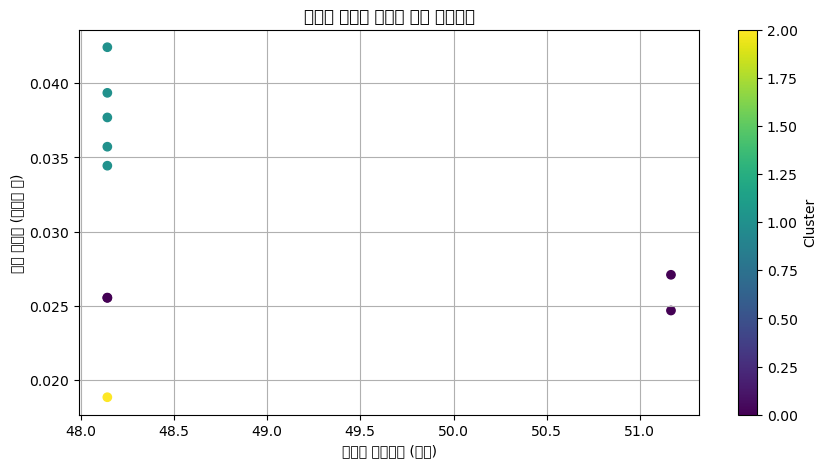

           지역   이벤트_유지일수     변화율_중  scaled_변화율  cluster
0   인천광역시 강화군  51.166667  0.027091   -0.549409        0
3    인천광역시 동구  48.142857  0.025534   -0.760954        0
5   인천광역시 부평구  48.142857  0.025555   -0.758012        0
8   인천광역시 옹진군  51.166667  0.024684   -0.876472        0
2   인천광역시 남동구  48.142857  0.035723    0.623400        1
4  인천광역시 미추홀구  48.142857  0.037695    0.891330        1
6    인천광역시 서구  48.142857  0.042427    1.534306        1
7   인천광역시 연수구  48.142857  0.039353    1.116662        1
9    인천광역시 중구  48.142857  0.034443    0.449515        1
1   인천광역시 계양구  48.142857  0.018840   -1.670366        2


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv")
df['일자'] = pd.to_datetime(df['일자'])
df = df.sort_values(['지역', '일자']).reset_index(drop=True)

# 이벤트 여부
df['캐시백_변동'] = df[['캐시백_상향', '캐시백_하향']].sum(axis=1)

results = []

# 지역별로 이벤트 기간 탐색
for region in df['지역'].unique():
    region_df = df[df['지역'] == region].reset_index(drop=True)
    is_event = False
    start_idx = None
    for i, row in region_df.iterrows():
        if row['캐시백_변동'] == 1 and not is_event:
            is_event = True
            start_idx = i
        elif row['캐시백_변동'] == 0 and is_event:
            end_idx = i - 1
            is_event = False

            # 이벤트 기간 정보
            duration = end_idx - start_idx + 1
            before = region_df.loc[max(0, start_idx - duration):start_idx - 1, '전체금액'].mean()
            during = region_df.loc[start_idx:end_idx, '전체금액'].mean()
            after = region_df.loc[end_idx + 1:end_idx + duration, '전체금액'].mean()

            if pd.notnull(before) and pd.notnull(during) and before > 0:
                delta_during = (during - before) / before
                delta_after = (after - before) / before if pd.notnull(after) else None

                results.append({
                    '지역': region,
                    '이벤트_유지일수': duration,
                    '변화율_중': delta_during,
                    '변화율_후': delta_after
                })

# 결과 데이터프레임
event_df = pd.DataFrame(results)

# 지역별 평균 소비 변화율 (중간 시점 기준)
summary = event_df.groupby('지역').agg({
    '이벤트_유지일수': 'mean',
    '변화율_중': 'mean'
}).reset_index()

# 표준화
scaler = StandardScaler()
summary[['scaled_변화율']] = scaler.fit_transform(summary[['변화율_중']])

# 군집 분석
kmeans = KMeans(n_clusters=3, random_state=42)
summary['cluster'] = kmeans.fit_predict(summary[['scaled_변화율']])

# 시각화
plt.figure(figsize=(10, 5))
plt.scatter(summary['이벤트_유지일수'], summary['변화율_중'], c=summary['cluster'], cmap='viridis')
plt.xlabel('캐시백 유지일수 (평균)')
plt.ylabel('소비 변화율 (이벤트 중)')
plt.title('지역별 캐시백 이벤트 반응 클러스터')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# 결과 보기
print(summary.sort_values('cluster'))


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\user\AppData\Local\Temp\ipykernel_22012\173210.py:67: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22012\173210.py:67: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22012\173210.py:67: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22012\173210.py:67: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22012\173210.py:67: UserWarning:

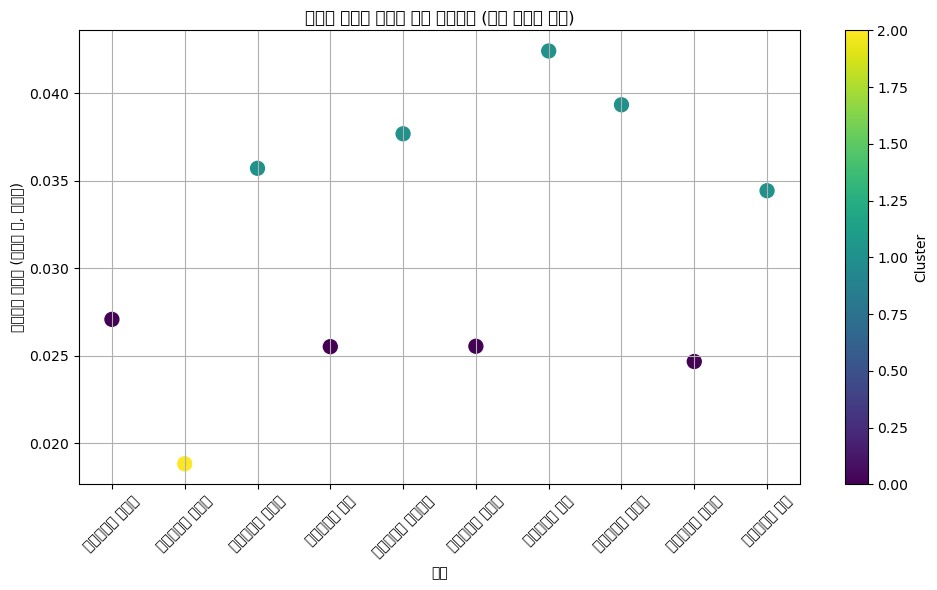

           지역     변화율_중  scaled_변화율  cluster
0   인천광역시 강화군  0.027091   -0.549409        0
3    인천광역시 동구  0.025534   -0.760954        0
5   인천광역시 부평구  0.025555   -0.758012        0
8   인천광역시 옹진군  0.024684   -0.876472        0
2   인천광역시 남동구  0.035723    0.623400        1
4  인천광역시 미추홀구  0.037695    0.891330        1
6    인천광역시 서구  0.042427    1.534306        1
7   인천광역시 연수구  0.039353    1.116662        1
9    인천광역시 중구  0.034443    0.449515        1
1   인천광역시 계양구  0.018840   -1.670366        2


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv")
df['일자'] = pd.to_datetime(df['일자'])
df = df.sort_values(['지역', '일자']).reset_index(drop=True)

# 캐시백 이벤트 유무
df['캐시백_변동'] = df[['캐시백_상향', '캐시백_하향']].sum(axis=1)

results = []

# 지역별 이벤트 분석
for region in df['지역'].unique():
    region_df = df[df['지역'] == region].reset_index(drop=True)
    is_event = False
    start_idx = None
    for i, row in region_df.iterrows():
        if row['캐시백_변동'] == 1 and not is_event:
            is_event = True
            start_idx = i
        elif row['캐시백_변동'] == 0 and is_event:
            end_idx = i - 1
            is_event = False

            # 유지일수는 무시 (계산은 해도 됨)
            before = region_df.loc[max(0, start_idx - (end_idx - start_idx + 1)):start_idx - 1, '전체금액'].mean()
            during = region_df.loc[start_idx:end_idx, '전체금액'].mean()

            if pd.notnull(before) and pd.notnull(during) and before > 0:
                delta_during = (during - before) / before

                results.append({
                    '지역': region,
                    '변화율_중': delta_during
                })

# 요약 데이터프레임 (평균 변화율만 계산)
summary = pd.DataFrame(results)
summary = summary.groupby('지역').agg({
    '변화율_중': 'mean'
}).reset_index()

# 변화율에 절대값 적용
summary['변화율_중'] = summary['변화율_중'].abs()

# 표준화
scaler = StandardScaler()
summary['scaled_변화율'] = scaler.fit_transform(summary[['변화율_중']])

# KMeans 군집 (변화율만)
kmeans = KMeans(n_clusters=3, random_state=42)
summary['cluster'] = kmeans.fit_predict(summary[['scaled_변화율']])

# 시각화 (x축은 지역, y축 변화율, 군집별 색상)
plt.figure(figsize=(10, 6))
plt.scatter(summary.index, summary['변화율_중'], c=summary['cluster'], cmap='viridis', s=100)
plt.xticks(summary.index, summary['지역'], rotation=45)
plt.xlabel('지역')
plt.ylabel('결제금액 변화율 (이벤트 중, 절대값)')
plt.title('지역별 캐시백 이벤트 반응 클러스터 (절대 변화율 기반)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# 결과 출력
print(summary.sort_values('cluster'))